In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE,
    FIGURE_SIZE_HALF,
    MARKER_STYLE,
    LINE_STYLE,
    GRID_STYLE,
    navy,
    bordeaux,
)
from analysis import from_round_one, cpu_seconds_per_round_per_node

FIG_DIR = "../figures/evaluation/anonymity"
os.makedirs(FIG_DIR, exist_ok=True)

CPU_LABEL = "Mean CPU time per round (s)"


def band(ax, x_values, series, color, linestyle="-"):

    ys_mean = [float(np.mean(series[x])) for x in x_values]
    ys_lo = [float(np.min(series[x])) for x in x_values]
    ys_hi = [float(np.max(series[x])) for x in x_values]

    ax.plot(x_values, ys_mean, color=color, linewidth=1.2, linestyle=linestyle, **MARKER_STYLE)
    ax.fill_between(x_values, ys_lo, ys_hi, color=color, alpha=0.2, linewidth=0)

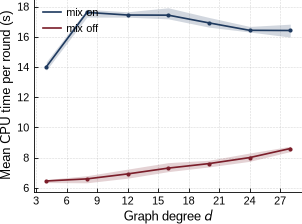

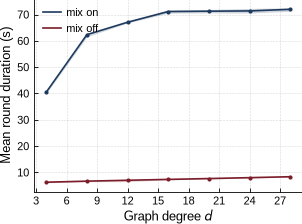

In [2]:
MIX_DIR = "../metrics/b1_mixing_baseline"


def mean_round_time_per_node(df):
    per_node_means = []

    for node, df_node in df.groupby("node"):
        round_times = pd.to_numeric(df_node[df_node.field == "round_time"].value)
        per_node_means.append(float(round_times.mean()))

    return per_node_means


cpu_by_degree = {True: {}, False: {}}
round_time_by_degree = {True: {}, False: {}}

for name, path in list_runs(MIX_DIR):

    if not name.startswith("mixdeg_deg"):
        continue

    # run names look like "mixdeg_deg04_mix_seed_0"
    name_parts = name[len("mixdeg_deg"):].split("_")
    degree = int(name_parts[0])
    mixing_on = name_parts[1] == "mix"

    config = read_config_from_csv(path)
    n_rounds = int(config["n_rounds"])

    df = from_round_one(load_file(path))
    cpu_seconds = cpu_seconds_per_round_per_node(df, n_rounds)
    round_times = mean_round_time_per_node(df)

    if degree not in cpu_by_degree[mixing_on]:
        cpu_by_degree[mixing_on][degree] = []
    cpu_by_degree[mixing_on][degree].append(float(np.mean(cpu_seconds)))

    if degree not in round_time_by_degree[mixing_on]:
        round_time_by_degree[mixing_on][degree] = []
    round_time_by_degree[mixing_on][degree].append(float(np.mean(round_times)))

fig_cpu, ax_cpu = plt.subplots(figsize=FIGURE_SIZE_HALF)

for mixing_on, color, label in ((True, navy, "mix on"), (False, bordeaux, "mix off")):

    x_values = sorted(cpu_by_degree[mixing_on])
    band(ax_cpu, x_values, cpu_by_degree[mixing_on], color)
    ax_cpu.plot([], [], color=color, label=label, **LINE_STYLE)

ax_cpu.set_xlabel(r"Graph degree $d$")
ax_cpu.set_ylabel(CPU_LABEL)
ax_cpu.grid(**GRID_STYLE)
ax_cpu.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_cpu.legend(loc="upper left", frameon=False)

plt.tight_layout()

save_figure(fig_cpu, f"{FIG_DIR}/cpu_vs_degree_mix.pdf")

plt.show()

fig_round_time, ax_round_time = plt.subplots(figsize=FIGURE_SIZE_HALF)

for mixing_on, color, label in ((True, navy, "mix on"), (False, bordeaux, "mix off")):
    x_values = sorted(round_time_by_degree[mixing_on])

    band(ax_round_time, x_values, round_time_by_degree[mixing_on], color)

    ax_round_time.plot([], [], color=color, label=label, **LINE_STYLE)

ax_round_time.set_xlabel(r"Graph degree $d$")
ax_round_time.set_ylabel("Mean round duration (s)")
ax_round_time.grid(**GRID_STYLE)

ax_round_time.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_round_time.legend(loc="upper left", frameon=False)
plt.tight_layout()

save_figure(fig_round_time, f"{FIG_DIR}/round_time_vs_degree_mix.pdf")

plt.show()

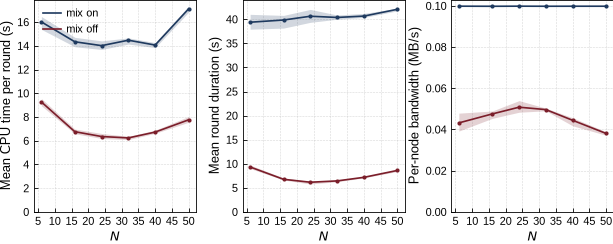

In [3]:
MIX_N_DIR = "../metrics/b1_mixing_baseline"


def bw_mbps_per_node(df):
    sent = df[df.field == "total_mbytes_sent"].copy()
    sent["v"] = pd.to_numeric(sent.value)
    sent = sent.sort_values(["node", "timestamp"])

    per_node_rates = []

    for node_id, node_rows in sent.groupby("node"):
        timestamps = node_rows.timestamp
        mbytes_sent = node_rows.v

        elapsed_seconds = (timestamps.iloc[-1] - timestamps.iloc[0]).total_seconds()
        mbytes_change = float(mbytes_sent.iloc[-1] - mbytes_sent.iloc[0])

        per_node_rates.append(mbytes_change / elapsed_seconds)

    return per_node_rates


cpu_by_n = {True: {}, False: {}}
round_time_by_n = {True: {}, False: {}}
bandwidth_by_n = {True: {}, False: {}}

for name, path in list_runs(MIX_N_DIR):

    if not name.startswith("mixn_n"):
        continue

    # run names look like "mixn_n40_mix_seed_0"
    name_parts = name[len("mixn_n"):].split("_")
    node_count = int(name_parts[0])
    mixing_on = name_parts[1] == "mix"

    config = read_config_from_csv(path)
    n_rounds = int(config["n_rounds"])

    df = from_round_one(load_file(path))
    cpu_seconds = cpu_seconds_per_round_per_node(df, n_rounds)
    round_times = mean_round_time_per_node(df)
    bandwidths = bw_mbps_per_node(df)

    if node_count not in cpu_by_n[mixing_on]:
        cpu_by_n[mixing_on][node_count] = []
    cpu_by_n[mixing_on][node_count].append(float(np.mean(cpu_seconds)))

    if node_count not in round_time_by_n[mixing_on]:
        round_time_by_n[mixing_on][node_count] = []
    round_time_by_n[mixing_on][node_count].append(float(np.mean(round_times)))

    if node_count not in bandwidth_by_n[mixing_on]:
        bandwidth_by_n[mixing_on][node_count] = []
    bandwidth_by_n[mixing_on][node_count].append(float(np.mean(bandwidths)))

fig, axes = plt.subplots(1, 3, figsize=FIGURE_SIZE)
series_by_label = (
    (cpu_by_n, "Mean CPU time per round (s)"),
    (round_time_by_n, "Mean round duration (s)"),
    (bandwidth_by_n, "Per-node bandwidth (MB/s)"),
)

for ax, (series, ylabel) in zip(axes, series_by_label):

    for mixing_on, color, label in ((True, navy, "mix on"), (False, bordeaux, "mix off")):

        x_values = sorted(series[mixing_on])
        band(ax, x_values, series[mixing_on], color)
        ax.plot([], [], color=color, label=label, **LINE_STYLE)

    ax.set_xlabel(r"$N$")
    ax.set_ylabel(ylabel)
    ax.grid(**GRID_STYLE)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_ylim(bottom=0)

axes[0].legend(loc="upper left", frameon=False)
plt.tight_layout()
save_figure(fig, f"{FIG_DIR}/mixing_cost_vs_n.pdf")

plt.show()